In [1]:
import numpy as np
import matplotlib.pyplot as plt

Taylor coefficients c_k (k=0..N):
  c_0 = 1
  c_1 = 1
  c_2 = -1.5
  c_3 = -1.83333333333
  c_4 = -0.291666666667
  c_5 = 0.341666666667
  ...

Fourier coefficients:
  a0 = -1.61303046861
  a_1 = 1.9728120659,  b_1 = -0.976832776863
  a_2 = -0.119021312925,  b_2 = 1.37585295191
  a_3 = -0.0869971187856,  b_3 = -0.696910514477
  a_4 = 0.0674942091567,  b_4 = 0.45662021199
  a_5 = -0.047603004375,  b_5 = -0.341659490737
  ...


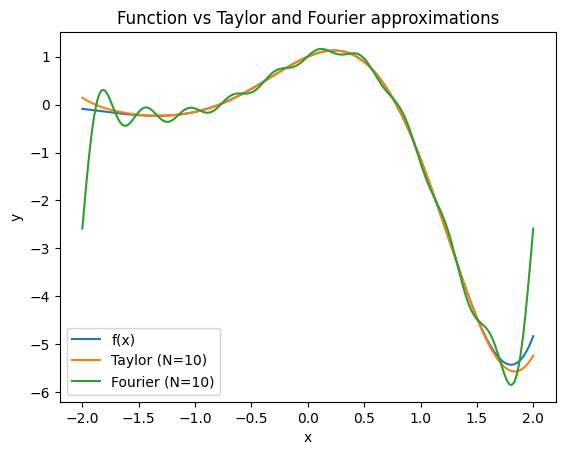

In [2]:
import math
import numpy as np

# Optional imports (used if available)
try:
    import sympy as sp
    HAS_SYMPY = True
except Exception:
    HAS_SYMPY = False

try:
    from scipy.integrate import quad
    HAS_SCIPY = True
except Exception:
    HAS_SCIPY = False


# ----------------------------
# 1) Define your function f(x)
# ----------------------------
# Numeric version used for integration/evaluation
def f_numpy(x: np.ndarray | float) -> np.ndarray | float:
    # EXAMPLE: f(x) = exp(x) * cos(2x)
    return np.exp(x) * np.cos(2 * x)

# Symbolic version used for Taylor if possible
# If sympy cannot represent your function easily, set this to None.
f_sympy_expr = None
if HAS_SYMPY:
    x = sp.Symbol("x")
    f_sympy_expr = sp.exp(x) * sp.cos(2 * x)


# -------------------------------------
# Utility: numerical derivative (fallback)
# -------------------------------------
def finite_diff_derivative(f, x0: float, k: int, h: float = 1e-5) -> float:
    """
    Approximate k-th derivative of f at x0 using recursive central differences.
    This is a simple fallback; for large k it gets noisy.
    """
    if k == 0:
        return float(f(x0))

    # Central difference for first derivative:
    # f'(x) ~ (f(x+h) - f(x-h)) / (2h)
    # For higher derivatives, differentiate the approximation recursively.
    def g(x):
        return (f(x + h) - f(x - h)) / (2.0 * h)

    return finite_diff_derivative(g, x0, k - 1, h)


# -------------------------------------
# 1) Taylor / Maclaurin polynomial up to N
# -------------------------------------
def taylor_maclaurin_coeffs(f, N: int, use_sympy: bool = True):
    """
    Returns coefficients [c0, c1, ..., cN] for sum_{k=0..N} c_k x^k
    """
    coeffs = []

    if use_sympy and HAS_SYMPY and f_sympy_expr is not None:
        x = sp.Symbol("x")
        expr = f_sympy_expr
        for k in range(N + 1):
            dk = sp.diff(expr, x, k)
            val = dk.subs(x, 0)
            ck = sp.N(val) / math.factorial(k)
            coeffs.append(float(ck))
        return coeffs

    # Fallback: numeric derivatives at 0
    for k in range(N + 1):
        d = finite_diff_derivative(f, 0.0, k)
        coeffs.append(d / math.factorial(k))
    return coeffs


def taylor_approx_function(coeffs):
    """
    Returns a callable p(x) evaluating the Taylor polynomial with given coeffs.
    coeffs[k] corresponds to x^k term.
    """
    coeffs = np.array(coeffs, dtype=float)

    def p(x):
        x_arr = np.asarray(x, dtype=float)
        # Horner evaluation
        y = np.zeros_like(x_arr, dtype=float)
        for c in coeffs[::-1]:
            y = y * x_arr + c
        return y

    return p


# -------------------------------------
# 2) Fourier series coefficients on [-L, L]
#    f(x) ~ a0/2 + sum_{n=1..N} [a_n cos(n pi x / L) + b_n sin(n pi x / L)]
# -------------------------------------
def _quad_integrate(func, a, b):
    if not HAS_SCIPY:
        raise RuntimeError("SciPy not available for quad integration.")
    val, _err = quad(func, a, b, limit=200)
    return val

def _trapz_integrate(func, a, b, M=20000):
    xs = np.linspace(a, b, M, endpoint=True)
    ys = func(xs)
    return float(np.trapz(ys, xs))

def fourier_coeffs(f, L: float, N: int, method: str = "auto"):
    """
    Returns (a0, a, b) where:
      a0 is scalar
      a[n-1] is a_n for n=1..N
      b[n-1] is b_n for n=1..N
    """
    if L <= 0:
        raise ValueError("L must be positive.")
    if N < 0:
        raise ValueError("N must be >= 0.")

    w = math.pi / L

    if method == "auto":
        integrate = _quad_integrate if HAS_SCIPY else _trapz_integrate
    elif method == "quad":
        integrate = _quad_integrate
    elif method == "trapz":
        integrate = _trapz_integrate
    else:
        raise ValueError("method must be one of: auto, quad, trapz")

    # a0 = (1/L) ∫_{-L..L} f(x) dx
    a0 = (1.0 / L) * integrate(lambda t: f(t), -L, L)

    a = np.zeros(N, dtype=float)
    b = np.zeros(N, dtype=float)

    for n in range(1, N + 1):
        an = (1.0 / L) * integrate(lambda t, n=n: f(t) * math.cos(n * w * t), -L, L)
        bn = (1.0 / L) * integrate(lambda t, n=n: f(t) * math.sin(n * w * t), -L, L)
        a[n - 1] = an
        b[n - 1] = bn

    return float(a0), a, b


def fourier_approx_function(L: float, a0: float, a: np.ndarray, b: np.ndarray):
    """
    Returns a callable S_N(x) for the Fourier partial sum up to N harmonics.
    """
    N = len(a)
    w = math.pi / L

    def S(x):
        x_arr = np.asarray(x, dtype=float)
        s = 0.5 * a0 * np.ones_like(x_arr, dtype=float)
        for n in range(1, N + 1):
            s += a[n - 1] * np.cos(n * w * x_arr) + b[n - 1] * np.sin(n * w * x_arr)
        return s

    return S


# -------------------------------------
# Demo / usage
# -------------------------------------
def main():
    L = 2.0      # interval is [-L, L]
    N = 10       # number of terms

    # Taylor
    tcoeffs = taylor_maclaurin_coeffs(lambda t: float(f_numpy(t)), N, use_sympy=True)
    pN = taylor_approx_function(tcoeffs)

    # Fourier
    a0, a, b = fourier_coeffs(lambda t: float(f_numpy(t)), L, N, method="auto")
    SN = fourier_approx_function(L, a0, a, b)

    # Evaluate on a grid
    xs = np.linspace(-L, L, 1000)
    fx = f_numpy(xs)
    px = pN(xs)
    sx = SN(xs)

    # Print a few coefficients
    print("Taylor coefficients c_k (k=0..N):")
    for k, ck in enumerate(tcoeffs[: min(6, N + 1)]):
        print(f"  c_{k} = {ck:.12g}")
    if N >= 6:
        print("  ...")

    print("\nFourier coefficients:")
    print(f"  a0 = {a0:.12g}")
    for n in range(1, min(6, N + 1)):
        print(f"  a_{n} = {a[n-1]:.12g},  b_{n} = {b[n-1]:.12g}")
    if N >= 6:
        print("  ...")

    # Optional plot
    try:
        import matplotlib.pyplot as plt
        plt.figure()
        plt.plot(xs, fx, label="f(x)")
        plt.plot(xs, px, label=f"Taylor (N={N})")
        plt.plot(xs, sx, label=f"Fourier (N={N})")
        plt.legend()
        plt.title("Function vs Taylor and Fourier approximations")
        plt.xlabel("x")
        plt.ylabel("y")
        plt.show()
    except Exception:
        pass


if __name__ == "__main__":
    main()